### Exercise 5.1

<br>

1) Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types.

2) Pick data from the following columns to a second dataframe `df2`: `y`, `job`, `marital`, `default`, `housing`, `poutcome`.

3) Convert categorical variables to dummy numerical values using the command

`df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])`

4) Produce a heat map of correlation coefficients for all variables in `df3`. Describe the amount of correlation between the variables in your own words.

5) Select the column called `y` of `df3` as the target variable `y`, and all the remaining columns for the explanatory variables `X`.

6) Split the dataset into training and testing sets with 75/25  ratio.

7) Setup a logistic regression model, train it with training data and predict on testing data.

8) Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.


### Exercise 5.2

Consider the data from CSV file `weight-height.csv`.

1) Read data into a pandas dataframe.

2) Pick the target variable `y` as weight in kilograms, and the feature variable `X` as height in centimeters.

3) Split the data into training and testing sets with 80/20 ratio.

4) Scale the training and testing data using normalization and standardization.

5) Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value.


## Exercise 5.1 – Bank marketing data: logistic regression

### 1) Read `bank.csv` and inspect the dataframe

Note: the file uses a semicolon (`;`) as the delimiter, not a comma, so we must pass `sep=';'` to `pd.read_csv`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('bank.csv', sep=';')

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

df.head()

Shape: (4521, 17)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


### 2) Select columns into `df2`

In [2]:
df2 = df[['y', 'job', 'marital', 'default', 'housing', 'poutcome']]
df2.head()

,y,job,marital,default,housing,poutcome
0,no,unemployed,married,no,no,unknown
1,no,services,married,no,yes,failure
2,no,management,single,no,yes,failure
3,no,management,married,no,yes,unknown
4,no,blue-collar,married,no,yes,unknown


### 3) Convert categorical variables to dummy numerical values

In [3]:
df3 = pd.get_dummies(df2, columns=['job', 'marital', 'default', 'housing', 'poutcome'])

# 'y' is still text ("yes"/"no"); convert it to numeric (1/0) so it can be
# used in the correlation matrix and as the target for the model below.
df3['y'] = df3['y'].map({'yes': 1, 'no': 0})

df3.head()

,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,marital_married,marital_single,default_no,default_yes,housing_no,housing_yes,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0,False,False,False,False,False,False,False,False,False,...,True,False,True,False,True,False,False,False,False,True
1,0,False,False,False,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
2,0,False,False,False,False,True,False,False,False,False,...,False,True,True,False,False,True,True,False,False,False
3,0,False,False,False,False,True,False,False,False,False,...,True,False,True,False,False,True,False,False,False,True
4,0,False,True,False,False,False,False,False,False,False,...,True,False,True,False,False,True,False,False,False,True


### 4) Correlation heat map

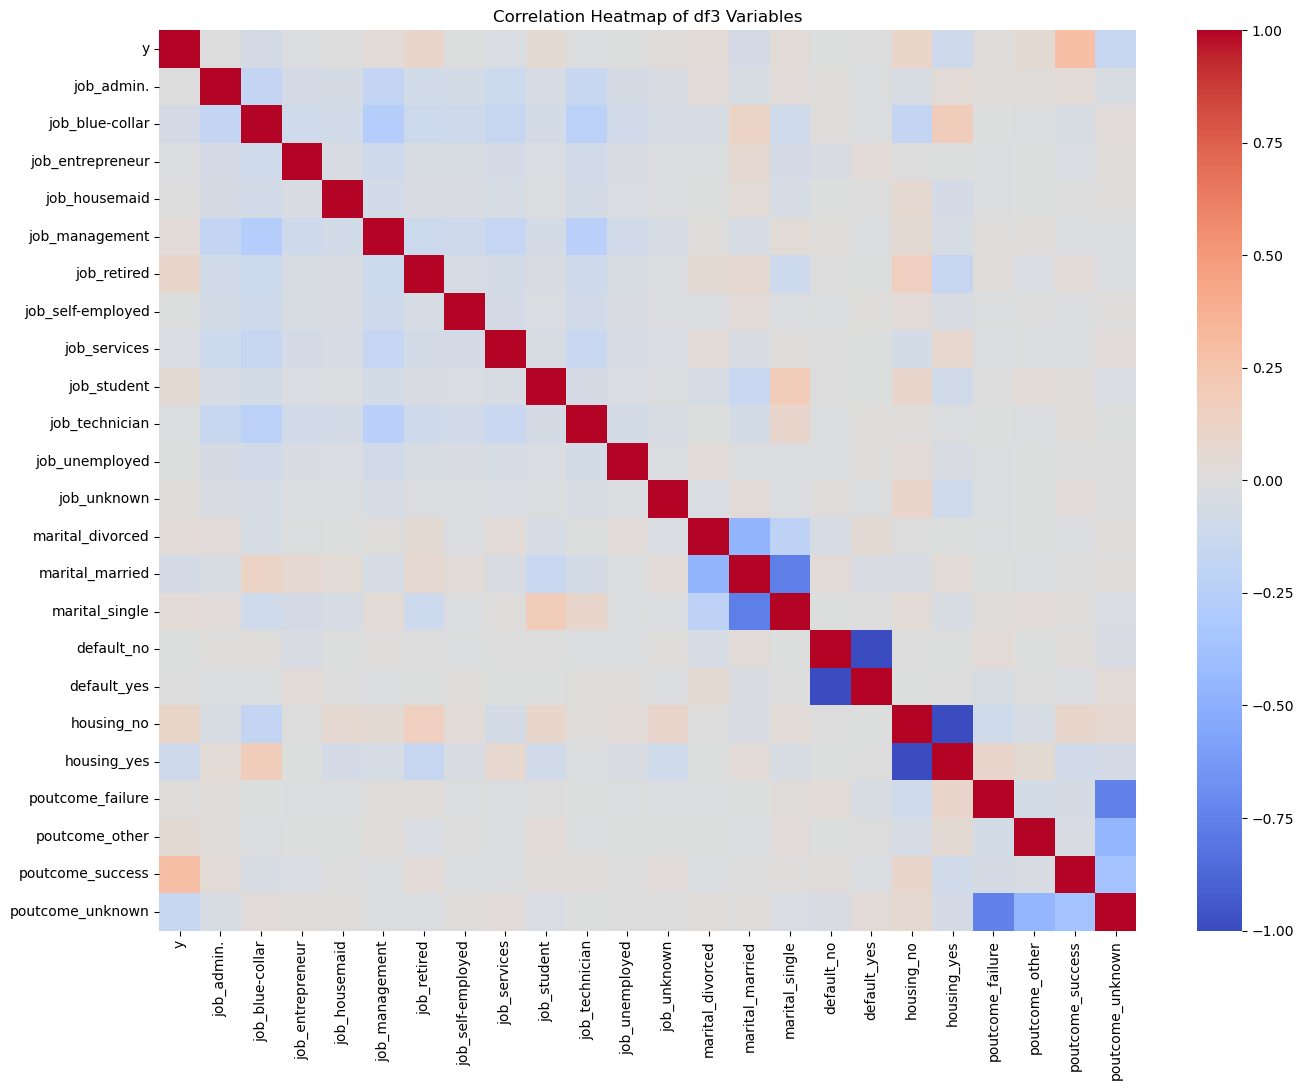

In [4]:
corr = df3.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of df3 Variables')
plt.tight_layout()
plt.show()

**Discussion (in own words):**

Overall, most variables in `df3` show fairly weak correlation with each other and with the target `y`. The strongest correlations are the structural/negative ones that come directly from how `get_dummies` was applied: for example, within the same original category, the dummy columns are strongly *negatively* correlated with each other (e.g. `housing_yes` and `housing_no`, or `default_yes` and `default_no`), since a client can only belong to one category, so one column being 1 forces the other(s) to be 0. This kind of correlation is an artifact of one-hot encoding rather than a meaningful relationship in the data.

Looking specifically at correlations with `y` (whether the client subscribed to a term deposit), the values are generally small in magnitude (typically well under 0.2 in absolute value). The most noticeable ones tend to be related to `poutcome` (the outcome of the previous marketing campaign) — `poutcome_success` correlates positively with `y`, and `poutcome_unknown`/`poutcome_failure` correlate negatively, suggesting that a previous successful campaign is associated with a higher chance of subscribing this time. Job, marital status, and housing/default status show only mild correlation with the target, indicating that none of these categorical variables alone is a strong individual predictor of subscription — a model will need to combine several variables to get good predictive power.

### 5) Select target `y` and explanatory variables `X`

In [5]:
y = df3['y']
X = df3.drop('y', axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4521, 23)
y shape: (4521,)


### 6) Train/test split (75/25)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

Training set: (3390, 23)
Testing set:  (1131, 23)


### 7) Logistic regression model

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 8) Confusion matrix and accuracy score

Confusion matrix:
[[997   9]
 [106  19]]

Accuracy score: 0.8983


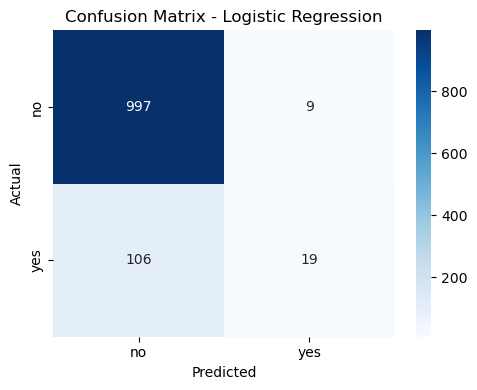

In [9]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion matrix:")
print(cm)
print(f"\nAccuracy score: {acc:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

**Note:** the dataset is imbalanced (far more "no" than "yes" outcomes), so the high overall accuracy is partly driven by the model's strong performance on the majority class. The confusion matrix shows the model predicts "no" correctly most of the time, but it captures only a portion of the actual "yes" cases — something to keep in mind beyond the raw accuracy score.

## Exercise 5.2 – Height/Weight data: KNN regression

### 1) Read data into a pandas dataframe

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

df_wh = pd.read_csv('weight-height.csv')
df_wh.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


### 2) Target `y` = weight in kg, feature `X` = height in cm

The raw data is in inches and pounds, so we convert it first.

In [11]:
df_wh['Height_cm'] = df_wh['Height'] * 2.54        # inches -> cm
df_wh['Weight_kg'] = df_wh['Weight'] * 0.453592      # pounds -> kg

X = df_wh[['Height_cm']]
y = df_wh['Weight_kg']

print(X.head())
print(y.head())

    Height_cm
0  187.571423
1  174.706036
2  188.239668
3  182.196685
4  177.499761
0    109.720985
1     73.622732
2     96.497550
3     99.809504
4     93.598619
Name: Weight_kg, dtype: float64


### 3) Train/test split (80/20)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

Training set: (8000, 1)
Testing set:  (2000, 1)


### 4) Scale the data: normalization and standardization

- **Normalization** (`MinMaxScaler`) rescales values to the range [0, 1].
- **Standardization** (`StandardScaler`) rescales values to have mean 0 and standard deviation 1.

The scaler is fit only on the training data and then applied (`transform`) to the test data, to avoid leaking test-set information into the scaling parameters.

In [13]:
# Normalization
minmax_scaler = MinMaxScaler()
X_train_norm = minmax_scaler.fit_transform(X_train)
X_test_norm = minmax_scaler.transform(X_test)

# Standardization
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

print("Normalized training sample:\n", X_train_norm[:5])
print("\nStandardized training sample:\n", X_train_std[:5])

Normalized training sample:
 [[0.28818819]
 [0.82611687]
 [0.57587754]
 [0.46630679]
 [0.52146168]]

Standardized training sample:
 [[-1.29189725]
 [ 2.16821664]
 [ 0.5586044 ]
 [-0.14618656]
 [ 0.20858579]]


### 5) KNN regression (k=5) without scaling

In [14]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R-squared (unscaled features): {r2:.4f}")

R-squared (unscaled features): 0.8346
